In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely
import pandas as pd
from geodatasets import get_path
import ast
# import geopy.distances
from tqdm import tqdm

import matplotlib as mpl
from matplotlib.colors import ListedColormap
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import gee_utils as gu
import vis_utils as vu
import sample_locations as sl
import loadpaths
path_dict_pecl = loadpaths.loadpaths()
# import shapely
# from tqdm import tqdm, tqdm_notebook
# import ast, shutil

In [3]:
import ee, geemap
import api_keys

ee.Authenticate()
ee.Initialize(project=api_keys.GEE_API)
geemap.ee_initialize()

In [ ]:
import ee
import geemap

ee.Initialize()

GRIP4_REGIONS = {
    "Africa":                   [-26,  -35,  52,   38],
    "Central-South-America":    [-82,  -56, -34,   15],
    "Europe":                   [-32,   28,  65,   72],
    "North-America":            [-180,  15, -52,   84],
    "Oceania":                  [ 94,  -55, 180,    2],
    "South-East-Asia":          [ 60,  -12, 150,   55],
    "Middle-East-Central-Asia": [ 25,   10,  90,   55],
}

REGION_COLORS = {
    "Africa":                   "#e6194b",
    "Central-South-America":    "#f58231",
    "Europe":                   "#3cb44b",
    "North-America":            "#4363d8",
    "Oceania":                  "#911eb4",
    "South-East-Asia":          "#42d4f4",
    "Middle-East-Central-Asia": "#f032e6",
}

def plot_grip4_regions(regions: dict, colors: dict) -> geemap.Map:
    """Plot bounding boxes from a {name: [W, S, E, N]} dict onto a geemap map."""
    m = geemap.Map(center=[20, 10], zoom=2)

    for name, (w, s, e, n) in regions.items():
        coords = [[w, s], [e, s], [e, n], [w, n], [w, s]]
        geojson = {
            "type": "FeatureCollection",
            "features": [{
                "type": "Feature",
                "geometry": {"type": "Polygon", "coordinates": [coords]},
                "properties": {"name": name}
            }]
        }
        color = colors.get(name, "#000000")
        m.add_geojson(geojson, layer_name=name, style={"color": color, "fillOpacity": 0.15, "weight": 2})

    return m

plot_grip4_regions(GRIP4_REGIONS, REGION_COLORS)

## Load all downloaded locations (with DW LC)

In [5]:
countries = gpd.read_file('../content/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')
gdf_points = pd.read_csv('../data/dw_locations_2026-02-13-1659_year-2024_50m_spherical_100k_random_stratified.csv')
gdf_points = gpd.GeoDataFrame(gdf_points, geometry=gpd.points_from_xy(gdf_points.lon, gdf_points.lat), crs='EPSG:4326')


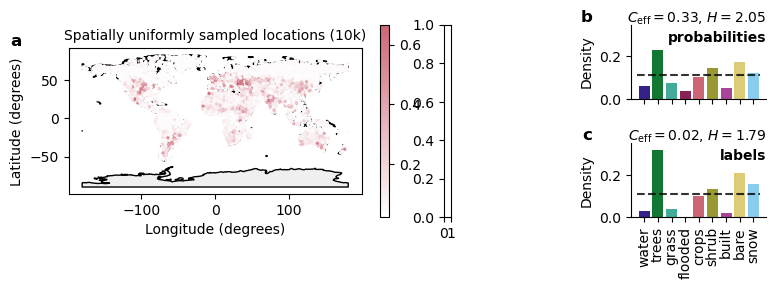

In [6]:
col_plot = 'crops'  # 'label' or any of the individual classes
save_fig = False
# type = 'lc_strat'
type = 'random'
assert type in ['random', 'lc_strat', 'all'], f"Invalid type: {type}. Must be one of 'random', 'lc_strat', or 'all'."

if type == 'random':
    gdf_plot = gdf_points[gdf_points.random_sample == 1]
elif type == 'lc_strat':
    gdf_plot = gdf_points[gdf_points.lc_stratified_sample == 1]
elif type == 'all':
    gdf_plot = gdf_points


# fig = plt.figure(figsize=(25, 10))
fig = plt.figure(figsize=(9, 2.5))

gs_map = plt.GridSpec(nrows=1, ncols=2, right=0.55, wspace=0.05, width_ratios=[1, 0.02])
gs_distr = plt.GridSpec(nrows=2, ncols=1, left=0.75, hspace=0.6)

ax_map = [fig.add_subplot(gs_map[ii]) for ii in range(2)]
ax_distr = [fig.add_subplot(gs_distr[ii]) for ii in range(2)]

cmap_dict = du.create_mpl_cmap_dynamic_world()
countries.plot(ax=ax_map[0], color="#EFEFEF", edgecolor='black')
gdf_plot.plot(ax=ax_map[0], column=col_plot, markersize=2, alpha=1,
                cmap=cmap_dict['all'] if col_plot == 'label' else cmap_dict['individual'][col_plot], 
                rasterized=True,
                legend=False if col_plot == 'label' else True)

if col_plot == 'label':
    dw_classes = du.DW_CLASSES
    dw_classes = [c.replace('_and', ' &').replace('_', '\n') for c in dw_classes]
    norm = mpl.colors.BoundaryNorm(
        boundaries=range(len(dw_classes) + 1),
        ncolors=len(dw_classes)
    )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_dict['all'])
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax_map[0],
        cax=ax_map[1],
        ticks=range(len(dw_classes)),
        shrink=0.67,
        pad=0.02
    )

    cbar.set_ticks(np.arange(len(dw_classes)) + 0.5, minor=False)
    cbar.set_ticks([], minor=True)
    cbar.set_ticklabels(dw_classes)

sum_dw_probs = gdf_plot[sl.DW_CLASSES].sum()
sum_dw_labels = np.array([np.sum(gdf_plot['label'] == i_dw) for i_dw, dw in enumerate(sl.DW_CLASSES)])

for i_ax, (sum_dw, name) in enumerate(zip([sum_dw_probs, sum_dw_labels], ['probabilities', 'labels'])):
    sum_dw = sum_dw / sum_dw.sum()  # normalize to sum to 1
    c_eff = np.min(sum_dw) / np.mean(sum_dw)
    means = np.mean(sum_dw)
    entropy = -np.sum(sum_dw * np.log(sum_dw + 1e-10))  # add small value to avoid log(0)
    perplexity = np.exp(entropy)

    ax_distr[i_ax].bar(sl.DW_CLASSES, sum_dw, 
                color=[du.create_cmap_dynamic_world()[dw] for dw in sl.DW_CLASSES])
    ax_distr[i_ax].set_ylabel('Density')
    ax_distr[i_ax].plot([-0.5, len(sl.DW_CLASSES) - 0.5], [1 / len(sl.DW_CLASSES)] * 2, 'k--', alpha=0.8)
    for sp in ['top', 'right']:
        ax_distr[i_ax].spines[sp].set_visible(False)  
    ax_distr[i_ax].set_xticks(range(len(sl.DW_CLASSES)))
    ax_distr[i_ax].annotate(f'{name}', weight='bold',
                            xy=(0.05, 0.925) if type == 'lc_strat' else (1, 0.925), xycoords='axes fraction', 
                            ha='left' if type == 'lc_strat' else 'right', va='top',)
    ax_distr[i_ax].annotate(r"$C_\text{eff}=$" f'{c_eff:.2f}, ' + r"$H=$" f'{entropy:.2f}', weight='normal',
                            xy=(1, 1.2), xycoords='axes fraction', ha='right', va='top',)

ax_map[0].set_xlabel('Longitude (degrees)')
ax_map[0].set_ylabel('Latitude (degrees)')
if type == 'random':
    ax_map[0].set_title(f'Spatially uniformly sampled locations ({len(gdf_plot) // 1000}k)', fontdict={'fontsize': 10})
elif type == 'lc_strat':
    ax_map[0].set_title(f'Land cover stratified sampled locations ({len(gdf_plot) // 1000}k)', fontdict={'fontsize': 10})
elif type == 'all':
    ax_map[0].set_title(f'All locations ({len(gdf_plot) // 1000}k)', fontdict={'fontsize': 10})
    
ax_distr[0].set_xticklabels([])    
ax_distr[1].set_xticklabels([x.split('_')[0] for x in sl.DW_CLASSES], rotation=90, ha='center')
# ymax = max(ax_distr[0].get_ylim()[1], ax_distr[1].get_ylim()[1])
ymax = 0.35
ax_distr[0].set_ylim(0, ymax)
ax_distr[1].set_ylim(0, ymax)


sys.path.append('/Users/tplas/repos/reproducible_figures/scripts')
import rep_fig_vis as rfv

rfv.add_panel_label(ax=ax_map[0], x_offset=-0.01, label_letter='a', fontsize=12)
rfv.add_panel_label(ax=ax_distr[0], x_offset=-0.01, label_letter='b', fontsize=12)
rfv.add_panel_label(ax=ax_distr[1], x_offset=-0.01, label_letter='c', fontsize=12)

if save_fig:
    plt.savefig(f'../../ms_neureo/figs/fig_map_{type}.pdf', bbox_inches='tight', dpi=600)
    plt.savefig(f'../figs/fig_map_{type}.pdf', bbox_inches='tight', dpi=600)


Text(0, 0.5, 'Number of samples')

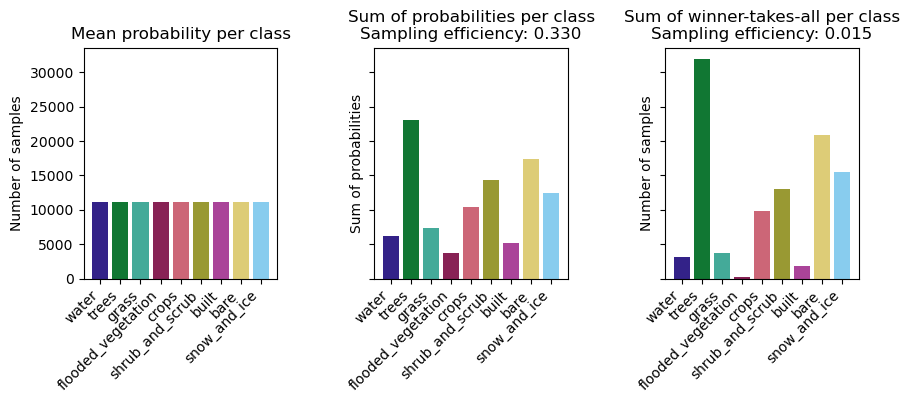

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), gridspec_kw={'wspace': 0.5}, sharey=True)
# for dw in sl.DW_CLASSES:
#     distr = gdf_points[dw].values
#     ax[0].hist(distr, bins=100, alpha=0.8, label=dw, color=du.create_cmap_dynamic_world()[dw], histtype='step')
# ax[0].set_yscale('log')
# ax[0].set_title('Distribution of probabilities\nper class')
# ax[0].set_xlabel('Probability')
# ax[0].set_ylabel('Count (log scale)')
mean = np.mean(gdf_points[sl.DW_CLASSES].values) * len(gdf_points)
ax[0].bar(sl.DW_CLASSES, mean, color=[du.create_cmap_dynamic_world()[dw] for dw in sl.DW_CLASSES])
ax[0].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
ax[0].set_title('Mean probability per class')
ax[0].set_ylabel('Number of samples')

sum_dw_probs = gdf_points[sl.DW_CLASSES].sum()
c_eff_probs = np.min(sum_dw_probs) / np.mean(sum_dw_probs)
ax[1].bar(sl.DW_CLASSES, sum_dw_probs, color=[du.create_cmap_dynamic_world()[dw] for dw in sl.DW_CLASSES])
ax[1].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
ax[1].set_title(f'Sum of probabilities per class\nSampling efficiency: {c_eff_probs:.3f}')
ax[1].set_ylabel('Sum of probabilities')

sum_dw_labels = [np.sum(gdf_points['label'] == i_dw) for i_dw, dw in enumerate(sl.DW_CLASSES)]
c_eff_labels = np.min(sum_dw_labels) / np.mean(sum_dw_labels)
ax[2].bar(sl.DW_CLASSES, sum_dw_labels, color=[du.create_cmap_dynamic_world()[dw] for dw in sl.DW_CLASSES])
ax[2].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
ax[2].set_title(f'Sum of winner-takes-all per class\nSampling efficiency: {c_eff_labels:.3f}')
ax[2].set_ylabel('Number of samples')

## Get a sample from the full dataset:

### Get single sample:

In [12]:
sample_strategy = 'flooded_vegetation'  # 'greedy', 'random', 'entropy', or any of the individual classes
size_sample = 10000
target_distr = np.array([1 / len(sl.DW_CLASSES)] * len(sl.DW_CLASSES))
if sample_strategy == 'greedy':
    sample_inds_best, c_eff, entropy = sl.sample_evenly_from_biased_distr(gdf_points=gdf_points, size_sample=size_sample, 
                                                                 ratio_start=0.15, ratio_prune=0.0, step_size=5)
    print(f'Greedy sampling: C_eff = {c_eff:.3f}, H = {entropy:.2f}, I = {np.exp(entropy):.2f}')
elif sample_strategy == 'random':

    max_it = 20000
    it = 0
    best = np.inf
    sample_inds_best = None
    while it < max_it:
        inds_sample = np.random.choice(len(gdf_points), size_sample, replace=False)
        sample = gdf_points.iloc[inds_sample]
        sum_sample = sample[sl.DW_CLASSES].sum()
        distr_sample = sum_sample / size_sample
        dist = np.linalg.norm(distr_sample - target_distr, ord=2)
        if dist < best:
            print(f"New best found at iteration {it}: distance {dist:.4f} (previous best: {best:.4f})")
            best = dist
            sample_inds_best = inds_sample
        it += 1

elif sample_strategy == 'entropy':
    entropy = - np.sum(target_distr * np.log(target_distr))
    entropy_points = - np.sum(gdf_points[sl.DW_CLASSES].values * np.log(gdf_points[sl.DW_CLASSES].values + 1e-10), axis=1)
    sample_inds_best = np.argsort(entropy_points)[-size_sample:]

elif sample_strategy in sl.DW_CLASSES:
    sample_inds_best = gdf_points.sort_values(sample_strategy, ascending=False).index[:size_sample]

### Optimise greedy sampler:

In [93]:

best_eff = -np.inf
size_sample = 10000
list_ratio_start = np.linspace(0, 0.5, num=11)[1:]
# list_ratio_prune = np.linspace(0, 0.2, num=5)
ratio_prune = 0  # empirically found that pruning does not improve.
list_step_size = [5, 10, 20, 30, 50]
step_size = 20
results = {x: [] for x in ['ratio_start', 'ratio_prune', 'step_size', 'c_eff', 'entropy']}
sample_inds_best = None
for ratio_start in list_ratio_start:
    # for ratio_prune in list_ratio_prune:
    for step_size in list_step_size:
        tmp, c_eff, entropy = sl.sample_evenly_from_biased_distr(gdf_points=gdf_points, size_sample=size_sample, 
                                                                            ratio_start=ratio_start, ratio_prune=ratio_prune, step_size=step_size)
        results['ratio_start'].append(ratio_start)
        results['ratio_prune'].append(ratio_prune)
        results['step_size'].append(step_size)
        results['c_eff'].append(c_eff)
        results['entropy'].append(entropy)
        if c_eff > best_eff:
            print(f"New best found: C_eff {c_eff:.4f} (previous best: {best_eff:.4f}) with ratio_start={ratio_start:.2f}, ratio_prune={ratio_prune:.2f}, step_size={step_size}")
            best_eff = c_eff
            sample_inds_best = tmp



New best found: C_eff 0.6030 (previous best: -inf) with ratio_start=0.05, ratio_prune=0.00, step_size=5
New best found: C_eff 0.6060 (previous best: 0.6030) with ratio_start=0.10, ratio_prune=0.00, step_size=5
New best found: C_eff 0.6060 (previous best: 0.6060) with ratio_start=0.15, ratio_prune=0.00, step_size=5


New best found: C_eff 0.6023 (previous best: -inf) with ratio_start=0.05, ratio_prune=0.00, step_size=5

New best found: C_eff 0.6060 (previous best: 0.6023) with ratio_start=0.10, ratio_prune=0.00, step_size=5

New best found: C_eff 0.6062 (previous best: 0.6060) with ratio_start=0.15, ratio_prune=0.00, step_size=5

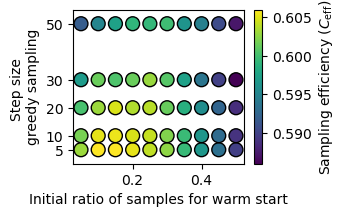

In [115]:
fig, ax = plt.subplots(figsize=(2.75, 2))
save_fig = True 

sc = ax.scatter(results['ratio_start'], results['step_size'], c=results['c_eff'], cmap='viridis', s=100, edgecolor='k')
ax.set_xlabel('Initial ratio of samples for warm start')
ax.set_ylabel('Step size \ngreedy sampling')
# ax.set_title('Sampling efficiency (C_eff) for different\nratio_start and step_size values')
ax.set_yticks(list_step_size)
ax.set_yticklabels(list_step_size)
ax.set_ylim(0, 55)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_ticks([0.59, 0.595, 0.6, 0.605])
cbar.set_label('Sampling efficiency ' + r"$(C_\text{eff})$")

if save_fig:
    plt.savefig(f'../../ms_neureo/figs/fig_sampler_optim.pdf', bbox_inches='tight')
    plt.savefig(f'../figs/fig_sampler_optim.pdf', bbox_inches='tight')

### Plot results:

/Users/tplas/repos/interpret_earth_embeddings/notebooks/../src/sample_locations.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_distr.set_xticklabels(DW_CLASSES, rotation=45, ha='right')
/Users/tplas/repos/interpret_earth_embeddings/notebooks/../src/sample_locations.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_distr.set_xticklabels(DW_CLASSES, rotation=45, ha='right')
/Users/tplas/repos/interpret_earth_embeddings/notebooks/../src/sample_locations.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_distr.set_xticklabels(DW_CLASSES, rotation=45, ha='right')


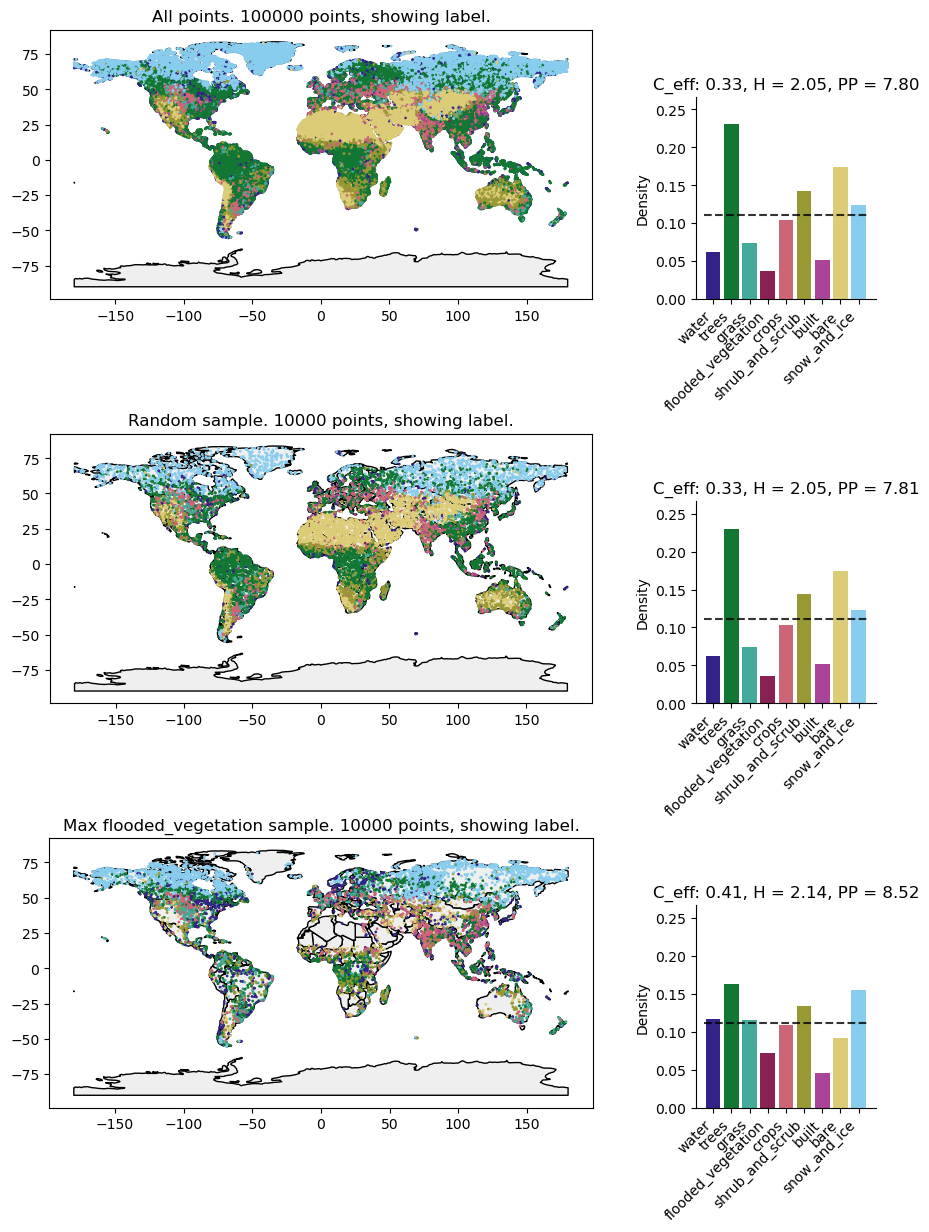

In [14]:
fig = plt.figure(figsize=(12, 14))
gs_map = plt.GridSpec(3, 1, hspace=0.5, right=0.75)
gs_distr = plt.GridSpec(3, 1, hspace=0.5, left=0.75)
ax_map = [fig.add_subplot(gs_map[i]) for i in range(3)]
ax_distr = [fig.add_subplot(gs_distr[i]) for i in range(3)]

sl.plot_map_and_distr(gdf=gdf_points, countries=countries, ax_map=ax_map[0], ax_distr=ax_distr[0], name='All points.')

inds_random = np.random.choice(len(gdf_points), size=size_sample, replace=False)
sl.plot_map_and_distr(gdf=gdf_points.iloc[inds_random], countries=countries, ax_map=ax_map[1], ax_distr=ax_distr[1], name='Random sample.')

sl.plot_map_and_distr(gdf=gdf_points.iloc[sample_inds_best], countries=countries, ax_map=ax_map[2], ax_distr=ax_distr[2], name='Max flooded_vegetation sample.')

ymax = 0
for ax_ in ax_distr:
    ymax = max(ymax, ax_.get_ylim()[1])
for ax_ in ax_distr:
    ax_.set_ylim(0, ymax * 1.1)
    box = ax_.get_position()
    ax_.set_position([box.x0, box.y0, box.width, box.height * 0.75])